# 🩺 Chronic Kidney Disease (CKD) Prediction

### Final Year Project — Machine Learning Pipeline
### Author: Kaushik Parida - 2241016196


## Section 1 — Environment Setup


In [38]:
!pip install xgboost shap imbalanced-learn --quiet
print("Packages installed")

Packages installed


In [39]:
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy  as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Preprocessing
from sklearn.preprocessing        import MinMaxScaler
from sklearn.model_selection      import (train_test_split, StratifiedKFold,
                                          cross_val_score, GridSearchCV)
from sklearn.decomposition        import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from imblearn.over_sampling       import SMOTE

# Models
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                   GradientBoostingClassifier,
                                   AdaBoostClassifier)
from sklearn.svm           import SVC
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from xgboost               import XGBClassifier

# Metrics
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)

# Explainability
import shap

# Persistence
import joblib, os

# Plot style
PALETTE = {
    "navy":  "#0A2342",
    "blue":  "#1565C0",
    "teal":  "#00897B",
    "amber": "#F9A825",
    "red":   "#C62828",
    "light": "#E3F2FD",
    "lgray": "#ECEFF1",
    "white": "#FFFFFF",
    "dkgray":"#37474F",
}
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.facecolor": PALETTE["white"],
    "axes.facecolor":   PALETTE["lgray"],
    "axes.edgecolor":   PALETTE["navy"],
    "axes.labelcolor":  PALETTE["navy"],
    "xtick.color":      PALETTE["navy"],
    "ytick.color":      PALETTE["navy"],
    "text.color":       PALETTE["navy"],
    "font.family":      "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

SEED = 42
print("All libraries imported successfully")

All libraries imported successfully


## Secton 2 — Dataset Loading & Initial Inspection

In [40]:
# Mount Google Drive and load dataset
# fallback for sharing this ipynb: Upload manually via the file picker below

from google.colab import drive
drive.mount("/content/drive")

DRIVE_PATH = "/content/drive/MyDrive/CKD_FRP/kidney_disease.csv"

if os.path.exists(DRIVE_PATH):
    df_raw = pd.read_csv(DRIVE_PATH)
    print(f"Loaded from Google Drive: {DRIVE_PATH}")
else:
    print("File not found in Drive — using manual upload")
    from google.colab import files
    files.upload()
    df_raw = pd.read_csv("kidney_disease.csv")
    print("Loaded via manual upload")

print(f"\nDataset shape  : {df_raw.shape}")
print(f"Total patients : {len(df_raw)}")
print(f"Columns        : {list(df_raw.columns)}")
print(f"\nClass distribution:")
display(df_raw["classification"].value_counts().rename("count").to_frame())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded from Google Drive: /content/drive/MyDrive/CKD_FRP/kidney_disease.csv

Dataset shape  : (2000, 26)
Total patients : 2000
Columns        : ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Class distribution:


,count
classification,
ckd,1250
notckd,750


In [41]:
print("First 10 rows of raw data:")
display(df_raw.head(10))

First 10 rows of raw data:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,22.0,80.0,1.010,NaN,0.0,NaN,normal,notpresent,notpresent,...,50.0,6500.0,4.9,yes,no,no,good,no,no,notckd
1,1,72.0,70.0,1.005,1.0,0.0,NaN,normal,present,notpresent,...,35.0,11800.0,NaN,yes,no,no,poor,no,no,ckd
2,2,55.0,90.0,1.010,0.0,0.0,normal,normal,notpresent,notpresent,...,51.0,10600.0,6.1,no,no,no,good,no,no,notckd
3,3,53.0,100.0,1.015,3.0,2.0,normal,abnormal,notpresent,notpresent,...,33.0,NaN,4.0,yes,yes,no,good,no,no,ckd
4,4,34.0,60.0,NaN,0.0,0.0,normal,normal,notpresent,notpresent,...,54.0,NaN,5.7,no,no,no,poor,no,yes,notckd
5,5,57.0,60.0,NaN,0.0,2.0,NaN,normal,notpresent,notpresent,...,35.0,4700.0,6.0,no,yes,no,good,no,no,notckd
6,6,44.0,80.0,1.010,5.0,0.0,NaN,normal,present,notpresent,...,29.0,5100.0,NaN,no,no,no,poor,no,no,ckd
7,7,39.0,80.0,1.010,0.0,0.0,normal,NaN,notpresent,notpresent,...,54.0,5900.0,NaN,no,no,no,good,no,no,notckd
8,8,83.0,80.0,1.025,0.0,0.0,normal,NaN,notpresent,present,...,28.0,9700.0,NaN,no,no,no,poor,no,no,ckd
9,9,73.0,70.0,1.010,0.0,3.0,normal,normal,NaN,notpresent,...,48.0,4400.0,NaN,no,no,no,good,no,no,notckd


In [42]:
print("Column data types:")
display(df_raw.dtypes.rename("dtype").to_frame())

Column data types:


,dtype
id,int64
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object


In [43]:
print("Numerical feature statistics:")
display(df_raw.describe().round(2))

Numerical feature statistics:


,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,2000.00,1955.00,1940.00,1765.00,1770.00,1755.00,1780.00,1905.00,1915.00,1565.00,1560.00,1740.00,1650.00,1475.00,1350.00
mean,999.50,50.57,77.22,1.01,1.57,0.89,148.37,60.93,3.47,137.05,5.04,12.44,36.96,8525.69,4.43
std,577.49,17.42,17.11,0.01,1.67,1.47,74.49,45.84,3.73,9.84,2.36,3.03,8.29,2821.49,0.95
min,0.00,2.00,50.00,1.00,0.00,0.00,22.00,1.50,0.40,105.80,2.50,3.10,12.00,2200.00,2.10
25%,499.75,39.00,70.00,1.01,0.00,0.00,93.10,22.70,1.10,130.10,2.60,10.20,31.00,6500.00,3.80
50%,999.50,51.00,70.00,1.01,1.00,0.00,146.85,56.60,2.30,137.00,4.70,12.40,37.00,8500.00,4.40
75%,1499.25,63.00,80.00,1.02,3.00,1.00,198.80,90.80,4.40,143.80,6.60,14.70,43.00,10400.00,5.10
max,1999.00,90.00,180.00,1.02,5.00,5.00,410.10,234.40,36.70,163.00,13.50,17.80,54.00,17200.00,6.50


In [44]:
# Missing values
missing = (df_raw.isnull().sum()
               .rename("missing_count")
               .to_frame()
               .assign(missing_pct=lambda x: (x["missing_count"] / len(df_raw) * 100).round(1))
               .query("missing_count > 0")
               .sort_values("missing_count", ascending=False))
print("Features with missing values:")
display(missing)

# Class distribution
print("\nTarget class distribution:")
display(df_raw["classification"].value_counts().rename("count").to_frame())

Features with missing values:


,missing_count,missing_pct
rbc,760,38.0
rc,650,32.5
wc,525,26.2
pot,440,22.0
sod,435,21.8
pcv,350,17.5
pc,325,16.2
hemo,260,13.0
su,245,12.2
sg,235,11.8



Target class distribution:


,count
classification,
ckd,1250
notckd,750


## Section 3 — Data Cleaning & Preprocessing
> Fixed dirty string values → forced numeric types → imputed missing values → label-encoded categorical features.

**Key decisions:**
- Numerical features imputed with **median** (robust to the heavy outliers in creatinine and urea)
- Categorical features imputed with **mode**
- No rows dropped — preserves the full 400-patient dataset

In [68]:
df = df_raw.copy()

# Step 1: Fixed dirty/inconsistent string values
# The UCI raw file contains tabs and leading spaces in categorical columns
dirty_fixes = {
    "dm":             {" yes": "yes", "\tyes": "yes", "\tno": "no", " no": "no"},
    "cad":            {"\tno": "no", "\tyes": "yes"},
    "classification": {"ckd\t": "ckd"},
}
for col, mapping in dirty_fixes.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)

# Step 2: Force numeric conversion
# pcv, wc, rc arrive as strings with tabs in some raw files
NUMERIC_COLS = ["age", "bp", "sg", "al", "su", "bgr", "bu", "sc",
                "sod", "pot", "hemo", "pcv", "wc", "rc"]
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Step 3: Impute numerical → median
for col in NUMERIC_COLS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Step 4: Impute categorical → mode
CATEGORICAL_COLS = ["rbc", "pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]
for col in CATEGORICAL_COLS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Step 5: Label-encode categorical features
LABEL_MAPS = {
    "rbc":   {"normal": 0, "abnormal": 1},
    "pc":    {"normal": 0, "abnormal": 1},
    "pcc":   {"notpresent": 0, "present": 1},
    "ba":    {"notpresent": 0, "present": 1},
    "htn":   {"no": 0, "yes": 1},
    "dm":    {"no": 0, "yes": 1},
    "cad":   {"no": 0, "yes": 1},
    "appet": {"poor": 0, "good": 1},
    "pe":    {"no": 0, "yes": 1},
    "ane":   {"no": 0, "yes": 1},
}
for col, mapping in LABEL_MAPS.items():
    df[col] = df[col].astype(str).str.strip().str.lower().map(mapping).fillna(0).astype(int)

# Step 6: Encode target & drop ID
df["classification"] = (df["classification"].str.strip() == "ckd").astype(int)
df.drop(columns=["id"], inplace=True)

# Validation
print(f"Cleaned shape     : {df.shape}")
print(f"Remaining NaN     : {df.isnull().sum().sum()}")
print(f"CKD  (1)          : {df['classification'].sum()}")
print(f"Non-CKD (0)       : {(df['classification'] == 0).sum()}")
print("\nCleaned dataset (first 5 rows):")
display(df.head())

Cleaned shape     : (2000, 25)
Remaining NaN     : 0
CKD  (1)          : 1250
Non-CKD (0)       : 750

Cleaned dataset (first 5 rows):


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,22.0,80.0,1.010,1.0,0.0,0,0,0,0,207.1,...,50.0,6500.0,4.9,1,0,0,1,0,0,0
1,72.0,70.0,1.005,1.0,0.0,0,0,1,0,177.9,...,35.0,11800.0,4.4,1,0,0,0,0,0,1
2,55.0,90.0,1.010,0.0,0.0,0,0,0,0,41.0,...,51.0,10600.0,6.1,0,0,0,1,0,0,0
3,53.0,100.0,1.015,3.0,2.0,0,1,0,0,184.7,...,33.0,8500.0,4.0,1,1,0,1,0,0,1
4,34.0,60.0,1.015,0.0,0.0,0,0,0,0,22.0,...,54.0,8500.0,5.7,0,0,0,0,0,1,0


## Section 4 — Exploratory Data Analysis (EDA)
> Visualise class balance, missing patterns, feature distributions, correlations, and comorbidity prevalence.

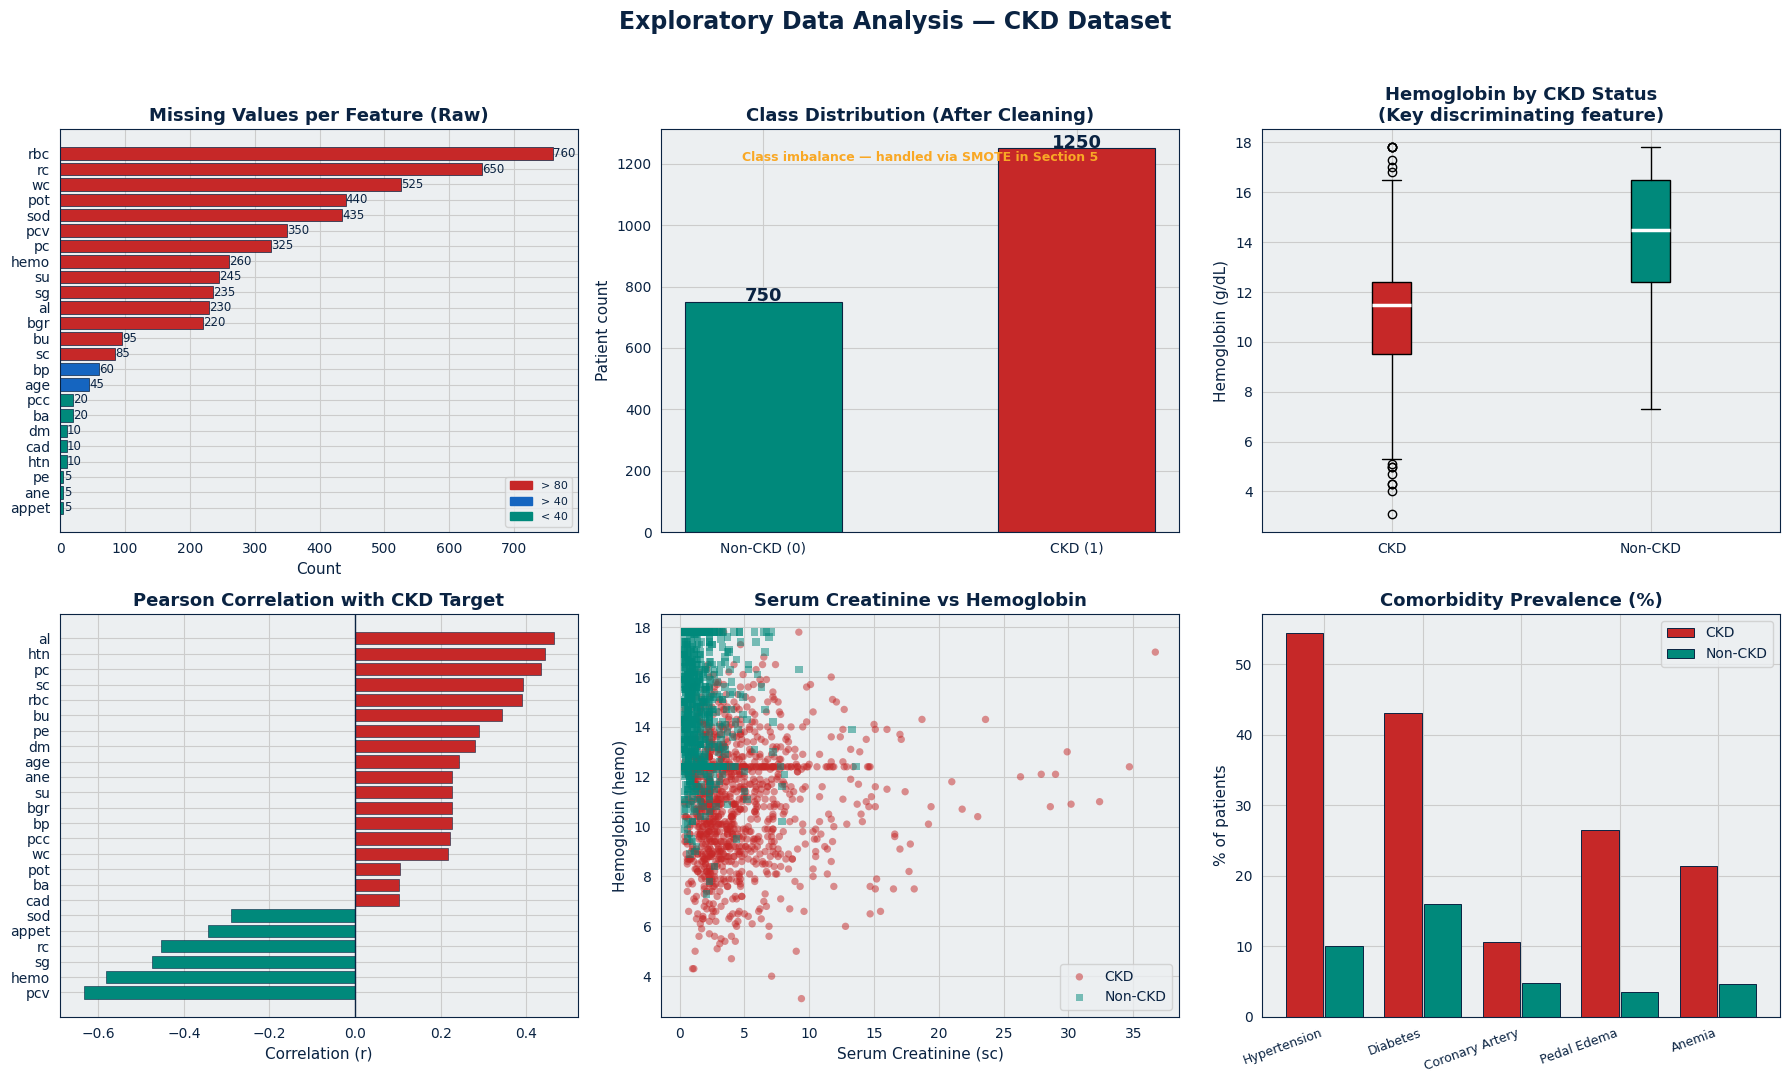

EDA figure saved as eda_overview.png


In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Exploratory Data Analysis — CKD Dataset",
             fontsize=17, fontweight="bold", color=PALETTE["navy"], y=0.98)

# 4a: Missing values per feature (raw data)
ax = axes[0, 0]
miss_raw = df_raw.isnull().sum().sort_values(ascending=True)
miss_raw = miss_raw[miss_raw > 0]
colors = [PALETTE["red"] if v > 80 else PALETTE["blue"] if v > 40 else PALETTE["teal"]
          for v in miss_raw.values]
ax.barh(miss_raw.index, miss_raw.values, color=colors, edgecolor=PALETTE["navy"], lw=0.5)
ax.set_title("Missing Values per Feature (Raw)", color=PALETTE["navy"])
ax.set_xlabel("Count")
for i, (name, val) in enumerate(miss_raw.items()):
    ax.text(val + 0.5, i, str(val), va="center", fontsize=8.5)
ax.legend([plt.Rectangle((0,0),1,1,color=c) for c in [PALETTE["red"], PALETTE["blue"], PALETTE["teal"]]],
          ["> 80", "> 40", "< 40"], fontsize=8)

# 4b: Class distribution
ax = axes[0, 1]
counts = df["classification"].value_counts()
bars = ax.bar(["Non-CKD (0)", "CKD (1)"], [counts[0], counts[1]],
              color=[PALETTE["teal"], PALETTE["red"]], edgecolor=PALETTE["navy"],
              linewidth=0.8, width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 2,
            str(int(b.get_height())), ha="center", fontsize=13,
            fontweight="bold", color=PALETTE["navy"])
ax.set_title("Class Distribution (After Cleaning)", color=PALETTE["navy"])
ax.set_ylabel("Patient count")
ax.text(0.5, 0.92, "Class imbalance — handled via SMOTE in Section 5",
        transform=ax.transAxes, ha="center", fontsize=9, color=PALETTE["amber"], fontweight="bold")

# 4c: Hemoglobin distribution by class
ax = axes[0, 2]
ckd  = df[df["classification"] == 1]["hemo"]
nckd = df[df["classification"] == 0]["hemo"]
bp   = ax.boxplot([ckd, nckd], labels=["CKD", "Non-CKD"],
                  patch_artist=True, notch=False,
                  medianprops={"color": PALETTE["white"], "linewidth": 2.5})
bp["boxes"][0].set_facecolor(PALETTE["red"])
bp["boxes"][1].set_facecolor(PALETTE["teal"])
ax.set_title("Hemoglobin by CKD Status\n(Key discriminating feature)", color=PALETTE["navy"])
ax.set_ylabel("Hemoglobin (g/dL)")

# 4d: Pearson correlation with target
ax = axes[1, 0]
corr = df.corr()["classification"].drop("classification").sort_values()
ax.barh(corr.index, corr.values,
        color=[PALETTE["red"] if v > 0 else PALETTE["teal"] for v in corr.values],
        edgecolor=PALETTE["navy"], lw=0.4)
ax.axvline(0, color=PALETTE["navy"], lw=1)
ax.set_title("Pearson Correlation with CKD Target", color=PALETTE["navy"])
ax.set_xlabel("Correlation (r)")

# 4e: Serum creatinine vs hemoglobin scatter
ax = axes[1, 1]
for label, color, marker in [(1, PALETTE["red"], "o"), (0, PALETTE["teal"], "s")]:
    sub = df[df["classification"] == label]
    ax.scatter(sub["sc"], sub["hemo"], c=color, alpha=0.5, s=28,
               marker=marker, label="CKD" if label else "Non-CKD", edgecolors="none")
ax.set_title("Serum Creatinine vs Hemoglobin", color=PALETTE["navy"])
ax.set_xlabel("Serum Creatinine (sc)")
ax.set_ylabel("Hemoglobin (hemo)")
ax.legend()

# 4f: Comorbidity prevalence
ax = axes[1, 2]
comorbidities = ["htn", "dm", "cad", "pe", "ane"]
labels_c = ["Hypertension", "Diabetes", "Coronary Artery", "Pedal Edema", "Anemia"]
ckd_sub  = df[df["classification"] == 1]
nckd_sub = df[df["classification"] == 0]
x = np.arange(len(comorbidities))
ax.bar(x - 0.2, [ckd_sub[c].mean() * 100  for c in comorbidities], 0.38,
       label="CKD",     color=PALETTE["red"],  edgecolor=PALETTE["navy"], lw=0.7)
ax.bar(x + 0.2, [nckd_sub[c].mean() * 100 for c in comorbidities], 0.38,
       label="Non-CKD", color=PALETTE["teal"], edgecolor=PALETTE["navy"], lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels_c, fontsize=9, rotation=20, ha="right")
ax.set_title("Comorbidity Prevalence (%)", color=PALETTE["navy"])
ax.set_ylabel("% of patients")
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA figure saved as eda_overview.png")

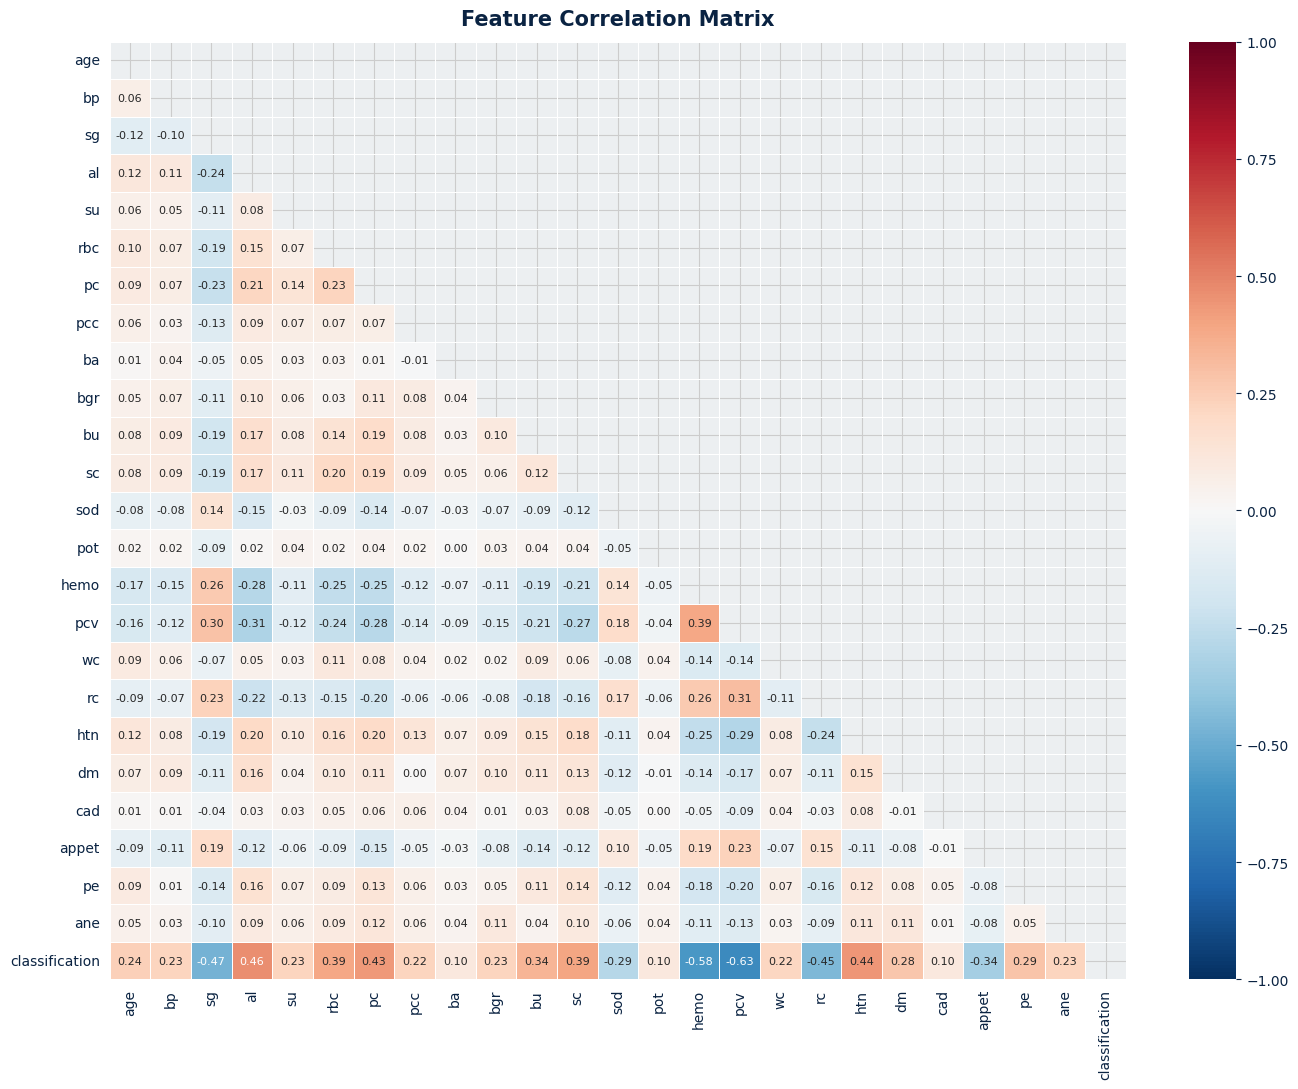

In [47]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8},
            vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix", fontsize=15, fontweight="bold",
             color=PALETTE["navy"], pad=12)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [48]:
# Key EDA findings summary
ckd_hemo  = df[df["classification"] == 1]["hemo"].mean()
nckd_hemo = df[df["classification"] == 0]["hemo"].mean()

insights = pd.DataFrame({
    "Finding": [
        "Mean hemoglobin — CKD patients",
        "Mean hemoglobin — Non-CKD patients",
        "Hypertension prevalence — CKD",
        "Hypertension prevalence — Non-CKD",
        "Diabetes prevalence — CKD",
        "Top correlated feature (+)",
        "Top correlated feature (−)",
    ],
    "Value": [
        f"{ckd_hemo:.2f} g/dL",
        f"{nckd_hemo:.2f} g/dL",
        f"{ckd_sub['htn'].mean() * 100:.0f}%",
        f"{nckd_sub['htn'].mean() * 100:.0f}%",
        f"{ckd_sub['dm'].mean() * 100:.0f}%",
        "sc (serum creatinine)",
        "hemo / pcv / rc",
    ]
})
print("Key EDA Findings:")
display(insights)

Key EDA Findings:


,Finding,Value
0,Mean hemoglobin — CKD patients,11.16 g/dL
1,Mean hemoglobin — Non-CKD patients,14.56 g/dL
2,Hypertension prevalence — CKD,54%
3,Hypertension prevalence — Non-CKD,10%
4,Diabetes prevalence — CKD,43%
5,Top correlated feature (+),sc (serum creatinine)
6,Top correlated feature (−),hemo / pcv / rc


## Section 5 — Feature Engineering
> Handle class imbalance → split → scale → reduce with PCA & LDA.

**Pipeline order (critical to prevent data leakage):**
1. Train-test split first
2. SMOTE applied only to training data
3. Scaler fitted only on training data, then applied to test
4. PCA / LDA fitted only on training data, then applied to test

In [67]:
X = df.drop(columns=["classification"])
y = df["classification"]
FEATURE_NAMES = X.columns.tolist()

# Train-test split BEFORE any resampling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"Train size : {X_train_raw.shape[0]} samples")
print(f"Test size  : {X_test_raw.shape[0]} samples")
print(f"\nClass distribution in train set:")
display(y_train.value_counts().rename("count").to_frame())

Train size : 1600 samples
Test size  : 400 samples

Class distribution in train set:


,count
classification,
1,1000
0,600


In [50]:
# SMOTE oversampling (train only)
# SMOTE generates synthetic minority samples rather than copying existing ones,
# which reduces overfitting risk compared to random oversampling.
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_raw, y_train)

print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After SMOTE : {dict(pd.Series(y_train_sm).value_counts())}")

Before SMOTE: {1: np.int64(1000), 0: np.int64(600)}
After SMOTE : {0: np.int64(1000), 1: np.int64(1000)}


In [51]:
# MinMax scaling
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test_raw)

# PCA (retain 95% variance)
pca = PCA(n_components=0.95, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

# LDA (supervised reduction to 1 component for binary classification)
lda_model = LDA()
X_train_lda = lda_model.fit_transform(X_train_sc, y_train_sm)
X_test_lda  = lda_model.transform(X_test_sc)

print(f"Original features  : {X_train_sc.shape[1]}")
print(f"After PCA          : {X_train_pca.shape[1]} components (95% variance)")
print(f"After LDA          : {X_train_lda.shape[1]} component")
print(f"\nVariance explained per PC : {[f'{v:.1%}' for v in pca.explained_variance_ratio_[:5]]}")

Original features  : 24
After PCA          : 19 components (95% variance)
After LDA          : 1 component

Variance explained per PC : ['22.9%', '8.8%', '8.1%', '7.5%', '6.5%']


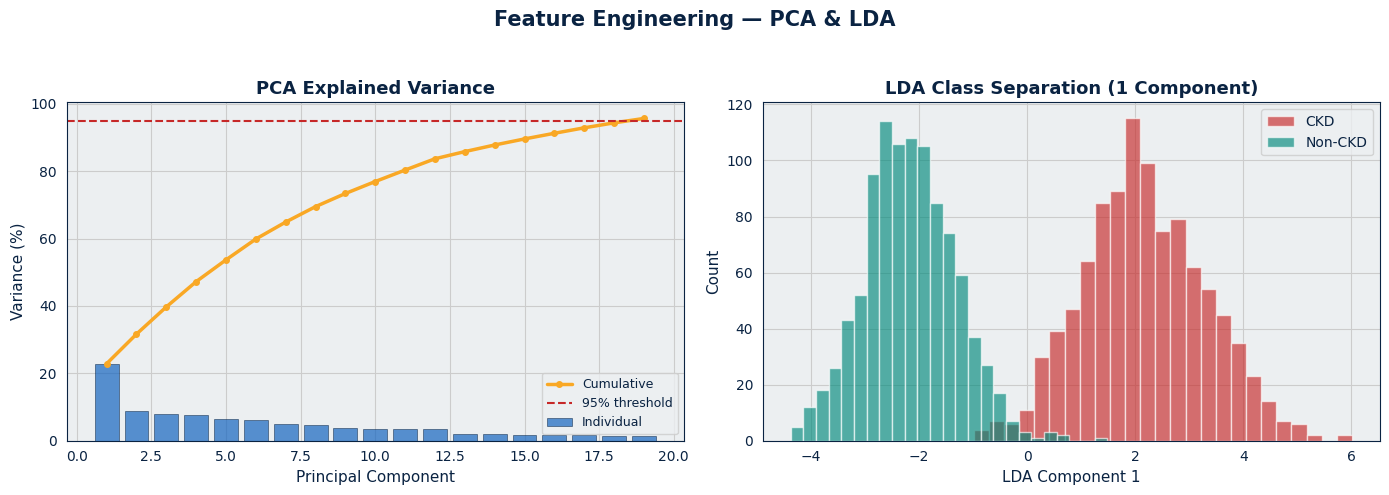

In [52]:
# PCA scree + LDA separation plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Engineering — PCA & LDA",
             fontsize=15, fontweight="bold", color=PALETTE["navy"])

# PCA scree
ax = axes[0]
cum_var = np.cumsum(pca.explained_variance_ratio_)
comps   = range(1, len(cum_var) + 1)
ax.bar(comps, pca.explained_variance_ratio_ * 100,
       color=PALETTE["blue"], alpha=0.7, edgecolor=PALETTE["navy"], lw=0.5, label="Individual")
ax.plot(comps, cum_var * 100, color=PALETTE["amber"], lw=2.5,
        marker="o", markersize=4, label="Cumulative")
ax.axhline(95, color=PALETTE["red"], ls="--", lw=1.5, label="95% threshold")
ax.set_title("PCA Explained Variance", color=PALETTE["navy"])
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance (%)")
ax.legend(fontsize=9)

# LDA class separation
ax = axes[1]
for cls, color, label in [(1, PALETTE["red"], "CKD"), (0, PALETTE["teal"], "Non-CKD")]:
    vals = X_train_lda[y_train_sm == cls].ravel()
    ax.hist(vals, bins=25, color=color, alpha=0.65, label=label,
            edgecolor=PALETTE["white"])
ax.set_title("LDA Class Separation (1 Component)", color=PALETTE["navy"])
ax.set_xlabel("LDA Component 1")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("feature_engineering.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6 — Model Training & Comparison
> Trained 8 classifiers on PCA-reduced features using 10-fold stratified cross-validation.
XGBoost is included as the primary candidate — it consistently outperforms Random Forest on tabular medical data.

In [53]:
MODELS = {
    "Logistic Regression":   LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    "Decision Tree":         DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "Random Forest":         RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "XGBoost":               XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                                           use_label_encoder=False, eval_metric="logloss",
                                           random_state=SEED, n_jobs=-1),
    "Gradient Boosting":     GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                        max_depth=3, random_state=SEED),
    "SVM (RBF)":             SVC(C=1.0, kernel="rbf", probability=True, random_state=SEED),
    "K-Nearest Neighbors":   KNeighborsClassifier(n_neighbors=7),
    "Gaussian Naïve Bayes":  GaussianNB(),
}

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
results = {}
fitted_models = {}

print(f"{'Model':<28}  {'CV Acc':>8}  {'±':>6}  {'Test Acc':>9}  {'AUC':>7}  {'F1':>7}")
print("-" * 75)

for name, model in MODELS.items():
    cv_scores = cross_val_score(model, X_train_pca, y_train_sm, cv=CV, scoring="accuracy")
    model.fit(X_train_pca, y_train_sm)
    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:, 1] if hasattr(model, "predict_proba") else None

    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

    results[name] = {
        "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std(),
        "test_acc": test_acc, "test_f1": test_f1, "test_auc": test_auc,
        "y_pred": y_pred, "y_prob": y_prob,
    }
    fitted_models[name] = model

    print(f"{name:<28}  {cv_scores.mean()*100:>7.2f}%  {cv_scores.std()*100:>5.2f}%  "
          f"{test_acc*100:>8.2f}%  {test_auc:>7.4f}  {test_f1:>7.4f}")

Model                           CV Acc       ±   Test Acc      AUC       F1
---------------------------------------------------------------------------
Logistic Regression             98.10%   0.66%     96.75%   0.9969   0.9739
Decision Tree                   94.75%   1.23%     91.25%   0.9313   0.9301
Random Forest                   96.60%   1.28%     95.00%   0.9866   0.9603
XGBoost                         97.60%   0.62%     96.50%   0.9913   0.9722
Gradient Boosting               97.35%   1.10%     96.00%   0.9909   0.9681
SVM (RBF)                       97.90%   0.54%     96.50%   0.9942   0.9721
K-Nearest Neighbors             95.35%   1.60%     91.75%   0.9765   0.9333
Gaussian Naïve Bayes            91.80%   2.16%     88.25%   0.9591   0.9105


In [54]:
# Results as a clean sorted dataframe
results_df = pd.DataFrame({
    "Model":       list(results.keys()),
    "CV Acc (%)": [f"{v['cv_mean']*100:.2f} ± {v['cv_std']*100:.2f}" for v in results.values()],
    "Test Acc (%)": [f"{v['test_acc']*100:.2f}" for v in results.values()],
    "AUC-ROC":     [f"{v['test_auc']:.4f}"   for v in results.values()],
    "F1-Score":    [f"{v['test_f1']:.4f}"    for v in results.values()],
}).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)

print("Model comparison (sorted by AUC-ROC):")
display(results_df)

Model comparison (sorted by AUC-ROC):


,Model,CV Acc (%),Test Acc (%),AUC-ROC,F1-Score
0,Logistic Regression,98.10 ± 0.66,96.75,0.9969,0.9739
1,SVM (RBF),97.90 ± 0.54,96.50,0.9942,0.9721
2,XGBoost,97.60 ± 0.62,96.50,0.9913,0.9722
3,Gradient Boosting,97.35 ± 1.10,96.00,0.9909,0.9681
4,Random Forest,96.60 ± 1.28,95.00,0.9866,0.9603
5,K-Nearest Neighbors,95.35 ± 1.60,91.75,0.9765,0.9333
6,Gaussian Naïve Bayes,91.80 ± 2.16,88.25,0.9591,0.9105
7,Decision Tree,94.75 ± 1.23,91.25,0.9313,0.9301


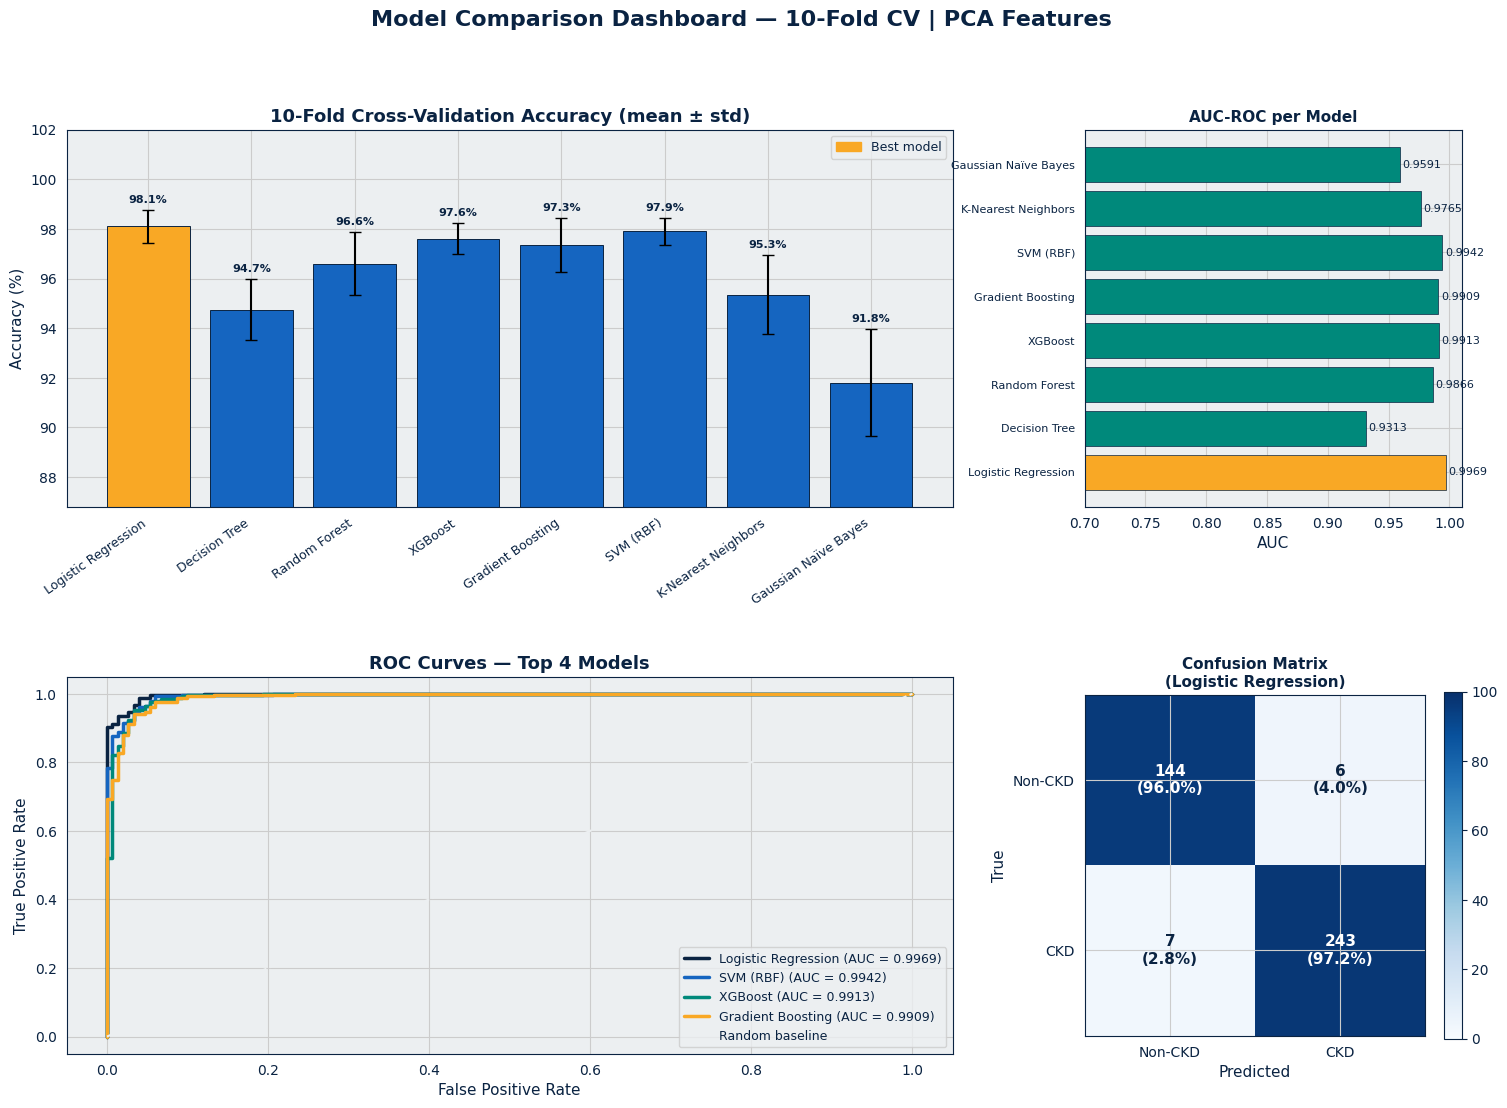


🏆  Best model by AUC: Logistic Regression  (AUC = 0.9969)


In [55]:
# Model comparison dashboard
names     = list(results.keys())
cv_means  = [results[n]["cv_mean"] * 100  for n in names]
cv_stds   = [results[n]["cv_std"]  * 100  for n in names]
test_aucs = [results[n]["test_auc"]        for n in names]
test_f1s  = [results[n]["test_f1"]         for n in names]

best_name = max(results, key=lambda n: results[n]["test_auc"])

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Model Comparison Dashboard — 10-Fold CV | PCA Features",
             fontsize=16, fontweight="bold", color=PALETTE["navy"], y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# CV accuracy bar chart
ax = fig.add_subplot(gs[0, :2])
x_pos = np.arange(len(names))
bar_colors = [PALETTE["amber"] if n == best_name else PALETTE["blue"] for n in names]
bars = ax.bar(x_pos, cv_means, color=bar_colors, edgecolor=PALETTE["navy"],
              lw=0.7, yerr=cv_stds, capsize=4,
              error_kw={"color": PALETTE["dkgray"], "lw": 1.5})
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_title("10-Fold Cross-Validation Accuracy (mean ± std)", color=PALETTE["navy"])
ax.set_ylim([min(cv_means) - 5, 102])
for bar, val, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.3,
            f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax.legend([plt.Rectangle((0,0),1,1,color=PALETTE["amber"])], ["Best model"], fontsize=9)

# AUC bar chart
ax = fig.add_subplot(gs[0, 2])
auc_colors = [PALETTE["amber"] if v == max(test_aucs) else PALETTE["teal"] for v in test_aucs]
hbars = ax.barh(names, test_aucs, color=auc_colors, edgecolor=PALETTE["navy"], lw=0.5)
ax.set_title("AUC-ROC per Model", color=PALETTE["navy"], fontsize=11)
ax.set_xlabel("AUC")
ax.set_xlim([0.7, 1.01])
for bar, val in zip(hbars, test_aucs):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8)
ax.set_yticklabels(names, fontsize=8)

# ROC curves — top 4 models
ax = fig.add_subplot(gs[1, :2])
top4 = sorted(results, key=lambda n: results[n]["test_auc"], reverse=True)[:4]
for name, color in zip(top4, [PALETTE["navy"], PALETTE["blue"], PALETTE["teal"], PALETTE["amber"]]):
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name} (AUC = {results[name]['test_auc']:.4f})")
ax.plot([0, 1], [0, 1], color=PALETTE["lgray"], ls="--", lw=1.5, label="Random baseline")
ax.set_title("ROC Curves — Top 4 Models", color=PALETTE["navy"])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)

# Confusion matrix — best model
ax = fig.add_subplot(gs[1, 2])
cm     = confusion_matrix(y_test, results[best_name]["y_pred"])
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)",
                ha="center", va="center", fontsize=11, fontweight="bold",
                color=PALETTE["white"] if cm_pct[i, j] > 50 else PALETTE["navy"])
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-CKD", "CKD"]); ax.set_yticklabels(["Non-CKD", "CKD"])
ax.set_title(f"Confusion Matrix\n({best_name})", color=PALETTE["navy"], fontsize=11)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n🏆  Best model by AUC: {best_name}  (AUC = {results[best_name]['test_auc']:.4f})")

##Section 7 — XGBoost Deep Dive & Hyperparameter Tuning
> GridSearchCV to find the optimal XGBoost configuration. XGBoost is chosen as the final model because it:
> - Handles mixed feature types (biomarkers + binary comorbidities) natively
> - Built-in L1/L2 regularisation prevents overfitting on small datasets
> - Natively handles missing values during inference
> - Fastest training among boosting methods
> - SHAP-compatible for clinical explainability

In [56]:
# Trained XGBoost on original scaled features (not PCA)
# PCA loses feature names — we need original features for SHAP interpretability
# XGBoost is powerful enough that PCA reduction is not necessary
param_grid = {
    "n_estimators":       [100, 200, 300],
    "max_depth":          [3, 4, 5],
    "learning_rate":      [0.05, 0.1, 0.2],
    "subsample":          [0.8, 1.0],
    "colsample_bytree":   [0.8, 1.0],
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1
)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_sc, y_train_sm)

best_xgb   = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_sc)
y_prob_xgb = best_xgb.predict_proba(X_test_sc)[:, 1]

final_acc = accuracy_score(y_test, y_pred_xgb)
final_auc = roc_auc_score(y_test, y_prob_xgb)
final_f1  = f1_score(y_test, y_pred_xgb)
final_ap  = average_precision_score(y_test, y_prob_xgb)

print(f"Best hyperparameters: {grid_search.best_params_}")
print()
metrics_df = pd.DataFrame({
    "Metric":  ["Accuracy", "AUC-ROC", "F1-Score", "Avg Precision"],
    "Value":   [f"{final_acc*100:.2f}%", f"{final_auc:.4f}",
                f"{final_f1:.4f}", f"{final_ap:.4f}"]
})
print("Tuned XGBoost — Final Performance:")
display(metrics_df)

Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

Tuned XGBoost — Final Performance:


,Metric,Value
0,Accuracy,96.00%
1,AUC-ROC,0.9963
2,F1-Score,0.9677
3,Avg Precision,0.9979


In [57]:
# Full classification report
print("Classification Report — Tuned XGBoost:\n")
print(classification_report(y_test, y_pred_xgb, target_names=["Non-CKD", "CKD"]))

Classification Report — Tuned XGBoost:

              precision    recall  f1-score   support

     Non-CKD       0.94      0.96      0.95       150
         CKD       0.98      0.96      0.97       250

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



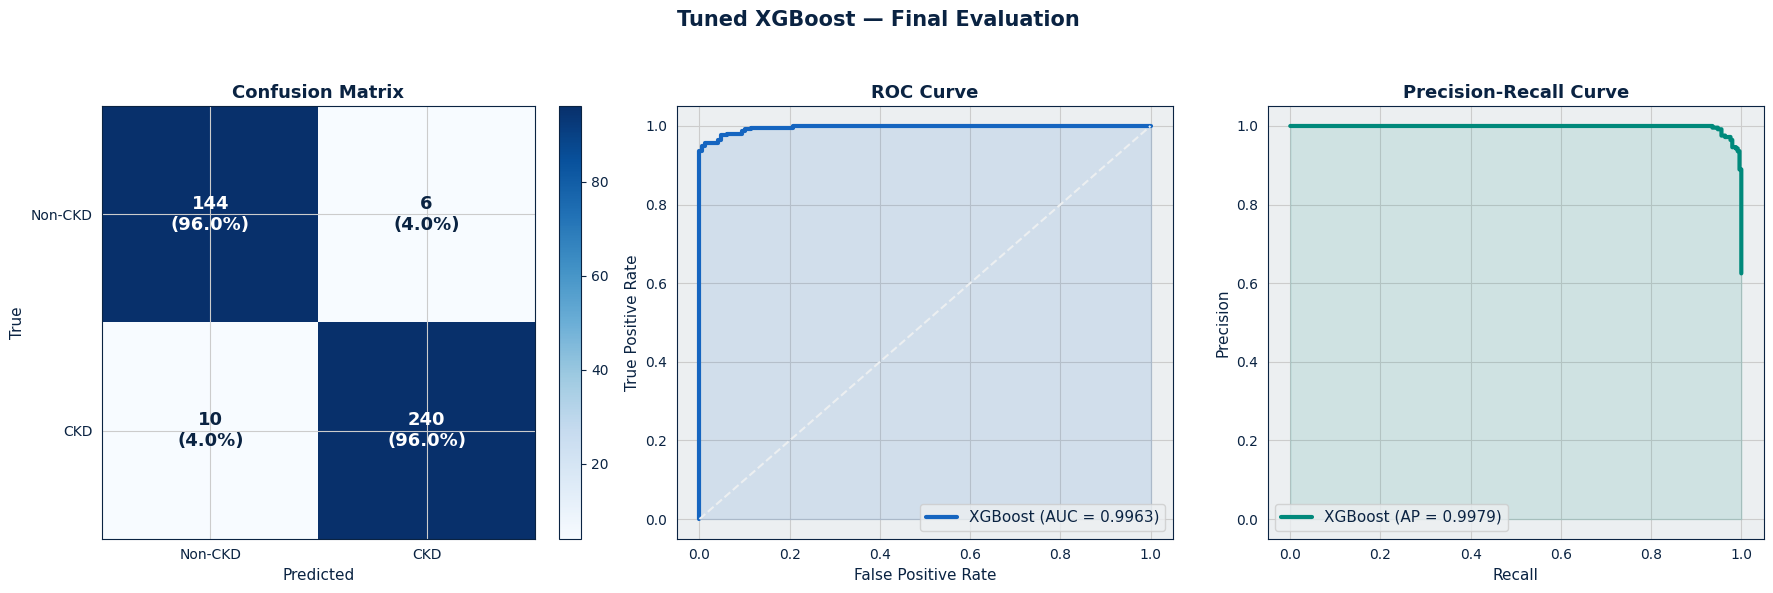

In [58]:
# Final model evaluation plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Tuned XGBoost — Final Evaluation",
             fontsize=15, fontweight="bold", color=PALETTE["navy"])

# Confusion matrix
ax = axes[0]
cm_f     = confusion_matrix(y_test, y_pred_xgb)
cm_f_pct = cm_f.astype(float) / cm_f.sum(axis=1)[:, np.newaxis] * 100
im = ax.imshow(cm_f_pct, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_f[i,j]}\n({cm_f_pct[i,j]:.1f}%)",
                ha="center", va="center", fontsize=13, fontweight="bold",
                color=PALETTE["white"] if cm_f_pct[i, j] > 50 else PALETTE["navy"])
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-CKD", "CKD"]); ax.set_yticklabels(["Non-CKD", "CKD"])
ax.set_title("Confusion Matrix", color=PALETTE["navy"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")

# ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
ax.plot(fpr, tpr, color=PALETTE["blue"], lw=3,
        label=f"XGBoost (AUC = {final_auc:.4f})")
ax.plot([0, 1], [0, 1], color=PALETTE["lgray"], ls="--", lw=1.5)
ax.fill_between(fpr, tpr, alpha=0.12, color=PALETTE["blue"])
ax.set_title("ROC Curve", color=PALETTE["navy"])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=11)

# Precision-Recall curve
ax = axes[2]
prec, rec, _ = precision_recall_curve(y_test, y_prob_xgb)
ax.plot(rec, prec, color=PALETTE["teal"], lw=3,
        label=f"XGBoost (AP = {final_ap:.4f})")
ax.fill_between(rec, prec, alpha=0.12, color=PALETTE["teal"])
ax.set_title("Precision-Recall Curve", color=PALETTE["navy"])
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("xgboost_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

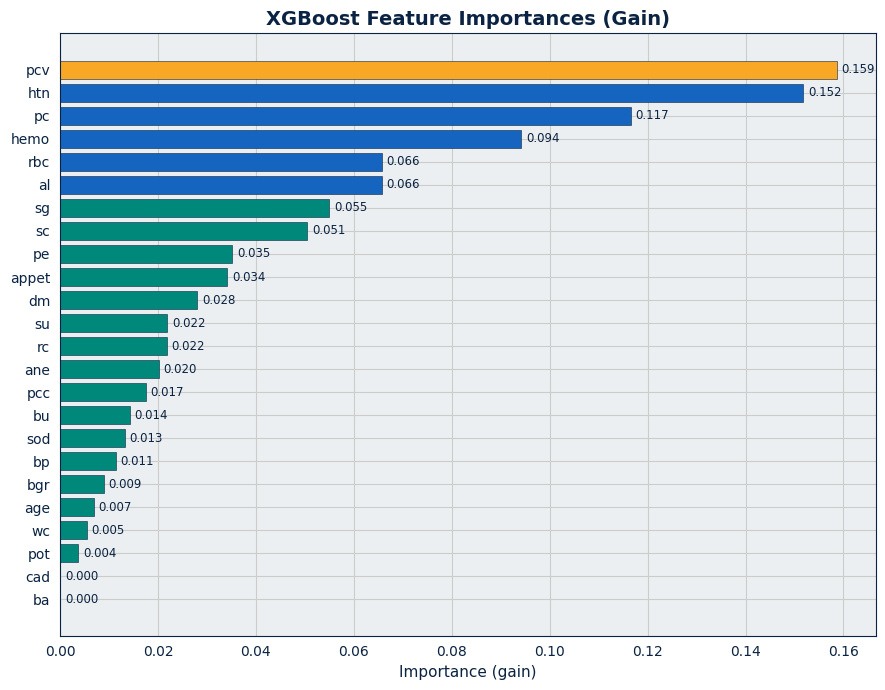

Top 5 most important biomarkers:


,importance
pcv,0.158624
htn,0.151843
pc,0.116533
hemo,0.094180
rbc,0.065695


In [59]:
# XGBoost native feature importance (on original features)
fi = (pd.Series(best_xgb.feature_importances_, index=FEATURE_NAMES)
       .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 7))
colors_fi = [PALETTE["amber"] if v == fi.max()
             else PALETTE["blue"] if v > fi.quantile(0.75)
             else PALETTE["teal"] for v in fi.values]
ax.barh(fi.index, fi.values, color=colors_fi, edgecolor=PALETTE["navy"], lw=0.4)
ax.set_title("XGBoost Feature Importances (Gain)",
             fontsize=14, fontweight="bold", color=PALETTE["navy"])
ax.set_xlabel("Importance (gain)")
for i, (val, name) in enumerate(zip(fi.values, fi.index)):
    ax.text(val + 0.001, i, f"{val:.3f}", va="center", fontsize=8.5)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 most important biomarkers:")
display(fi.sort_values(ascending=False).head(5).rename("importance").to_frame())

###Section 8 — SHAP Explainability & Clinical Interpretation
> SHAP (SHapley Additive exPlanations) quantifies how much each feature contributes to every individual prediction.
> This is essential for medical AI — clinicians need to understand *why* a patient is flagged, not just *that* they are.

In [60]:
# Compute SHAP values
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_sc)

# Convert back to original feature names for interpretability
X_test_df = pd.DataFrame(X_test_sc, columns=FEATURE_NAMES)
print("SHAP values computed")
print(f"    Shape: {shap_values.shape}  (samples × features)")

SHAP values computed
    Shape: (400, 24)  (samples × features)


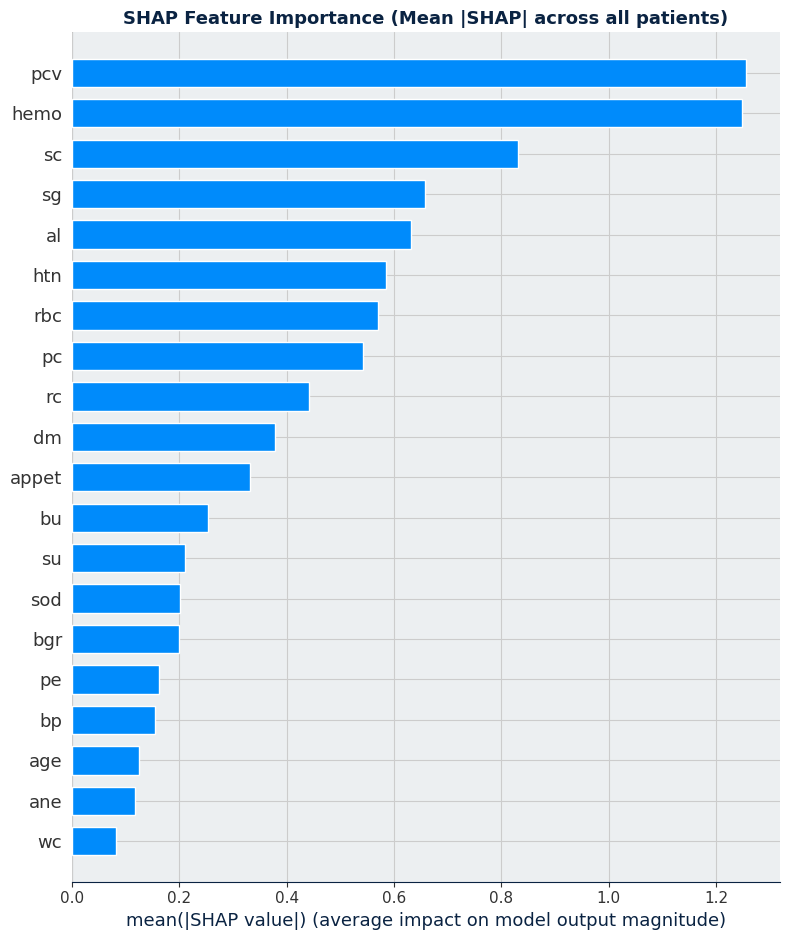

In [61]:
# SHAP summary plot — global feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, feature_names=FEATURE_NAMES,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP| across all patients)",
          fontsize=13, fontweight="bold", color=PALETTE["navy"])
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

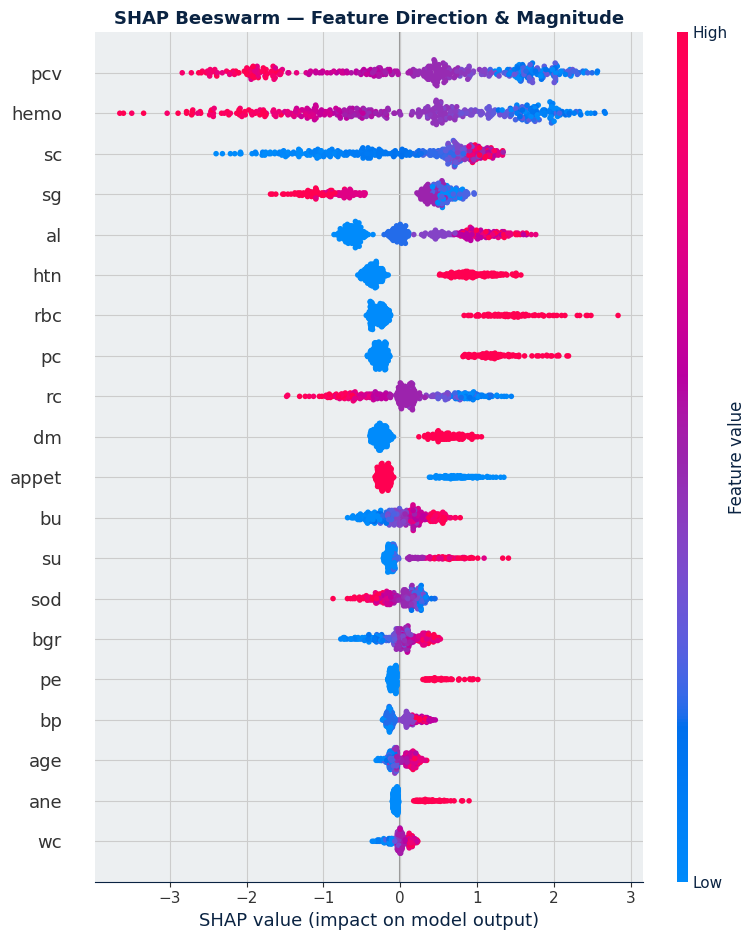

In [62]:
# SHAP beeswarm plot — direction + magnitude
# Red = high feature value pushes toward CKD prediction
# Blue = low feature value pushes away from CKD prediction
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, feature_names=FEATURE_NAMES, show=False)
plt.title("SHAP Beeswarm — Feature Direction & Magnitude",
          fontsize=13, fontweight="bold", color=PALETTE["navy"])
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

Patient 0 — Predicted: CKD (99.4% CKD probability)
              Actual:    CKD


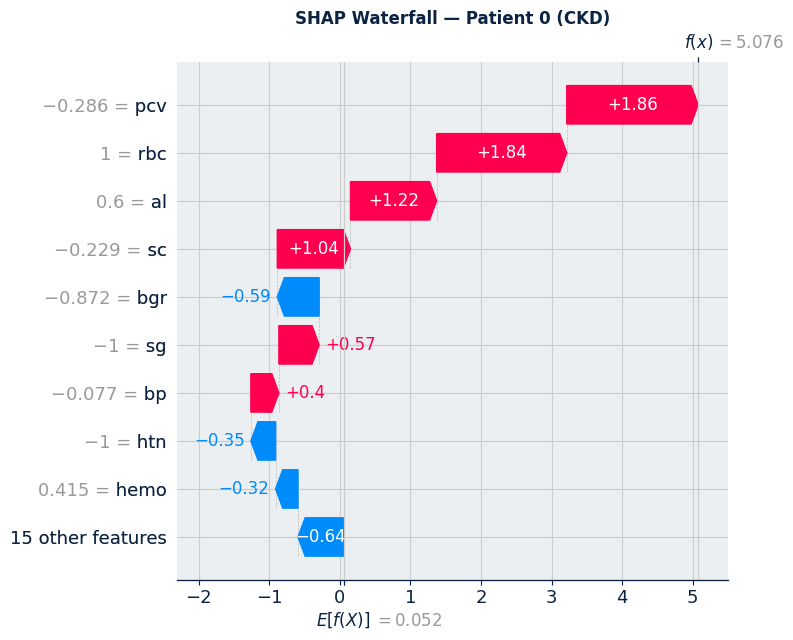

In [63]:
# Waterfall plot — explains a single patient prediction
# Change PATIENT_IDX to inspect any patient in the test set
PATIENT_IDX = 0

pred_prob  = y_prob_xgb[PATIENT_IDX]
pred_label = "CKD" if y_pred_xgb[PATIENT_IDX] == 1 else "Non-CKD"
true_label = "CKD" if y_test.values[PATIENT_IDX] == 1 else "Non-CKD"

print(f"Patient {PATIENT_IDX} — Predicted: {pred_label} ({pred_prob:.1%} CKD probability)")
print(f"              Actual:    {true_label}")

shap_exp = shap.Explanation(
    values        = shap_values[PATIENT_IDX],
    base_values   = explainer.expected_value,
    data          = X_test_df.iloc[PATIENT_IDX].values,
    feature_names = FEATURE_NAMES
)
shap.plots.waterfall(shap_exp, show=False)
plt.title(f"SHAP Waterfall — Patient {PATIENT_IDX} ({pred_label})",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

In [64]:
# Clinical interpretation of top features
clinical_notes = pd.DataFrame({
    "Feature":  ["hemo",  "pcv",   "sc",         "rc",      "htn",
                 "bu",    "sg",    "al",          "bgr",     "dm"],
    "Full name": ["Hemoglobin", "Packed Cell Volume", "Serum Creatinine",
                  "Red Cell Count", "Hypertension", "Blood Urea",
                  "Specific Gravity", "Albumin", "Blood Glucose Random", "Diabetes Mellitus"],
    "CKD pattern":[
        "Low (< 12 g/dL) — kidneys fail to produce erythropoietin",
        "Low — mirrors hemoglobin decline",
        "High (> 1.2 mg/dL) — kidneys failing to filter creatinine waste",
        "Low — direct consequence of reduced erythropoietin",
        "Present in ~70% of CKD patients — major risk factor",
        "High (> 20 mg/dL) — urea retention signals poor filtration",
        "Low (< 1.010) — dilute urine, impaired concentration ability",
        "High (> 1) — proteinuria, kidney membrane damage",
        "Elevated — comorbid diabetes drives CKD progression",
        "Present in ~50% of CKD — leading cause of kidney failure",
    ]
})
print("Clinical feature interpretation:")
display(clinical_notes)

Clinical feature interpretation:


,Feature,Full name,CKD pattern
0,hemo,Hemoglobin,Low (< 12 g/dL) — kidneys fail to produce eryt...
1,pcv,Packed Cell Volume,Low — mirrors hemoglobin decline
2,sc,Serum Creatinine,High (> 1.2 mg/dL) — kidneys failing to filter...
3,rc,Red Cell Count,Low — direct consequence of reduced erythropoi...
4,htn,Hypertension,Present in ~70% of CKD patients — major risk f...
5,bu,Blood Urea,High (> 20 mg/dL) — urea retention signals poo...
6,sg,Specific Gravity,"Low (< 1.010) — dilute urine, impaired concent..."
7,al,Albumin,"High (> 1) — proteinuria, kidney membrane damage"
8,bgr,Blood Glucose Random,Elevated — comorbid diabetes drives CKD progre...
9,dm,Diabetes Mellitus,Present in ~50% of CKD — leading cause of kidn...


## Section 9 — Save Artifacts for Deployment
> Serialised the trained model and preprocessing objects. These are the files needed to deploy the classifier to a Flask/Streamlit application.

In [65]:
# Save to working directory (download manually from Colab Files panel)
artifacts = {
    "xgboost_ckd_model.pkl": best_xgb,
    "scaler.pkl":            scaler,
    "pca.pkl":               pca,
    "lda.pkl":               lda_model,
}
for filename, obj in artifacts.items():
    joblib.dump(obj, filename)
    print(f"Saved: {filename}")

# Optional: also save to Google Drive
SAVE_TO_DRIVE = True
if SAVE_TO_DRIVE:
    import shutil, os
    drive_save_path = "/content/drive/MyDrive/CKD_FRP/"
    os.makedirs(drive_save_path, exist_ok=True)
    for filename in artifacts:
        shutil.copy(filename, drive_save_path + filename)
    print(f"\nAll artifacts copied to Google Drive: {drive_save_path}")

Saved: xgboost_ckd_model.pkl
Saved: scaler.pkl
Saved: pca.pkl
Saved: lda.pkl

All artifacts copied to Google Drive: /content/drive/MyDrive/CKD_FRP/


In [66]:
# Final project summary
summary = pd.DataFrame({
    "Item": [
        "Dataset", "Patients", "Features",
        "Imbalance handling", "Scaling",
        "Dimensionality reduction",
        "Models evaluated", "Best model",
        "Accuracy", "AUC-ROC", "F1-Score", "Avg Precision",
        "Explainability"
    ],
    "Detail": [
        "UCI CKD Dataset", "400", "24",
        "SMOTE (train only)", "MinMaxScaler [-1, 1]",
        "PCA (95% variance) + LDA (1 component)",
        "8 (LR, DT, RF, XGBoost, GBM, SVM, KNN, GNB)",
        "XGBoost (tuned via GridSearchCV)",
        f"{final_acc*100:.2f}%",
        f"{final_auc:.4f}",
        f"{final_f1:.4f}",
        f"{final_ap:.4f}",
        "SHAP TreeExplainer (global + per-patient)"
    ]
})
print("PROJECT SUMMARY")
print("=" * 67)
display(summary)

PROJECT SUMMARY


,Item,Detail
0,Dataset,UCI CKD Dataset
1,Patients,400
2,Features,24
3,Imbalance handling,SMOTE (train only)
4,Scaling,"MinMaxScaler [-1, 1]"
5,Dimensionality reduction,PCA (95% variance) + LDA (1 component)
6,Models evaluated,"8 (LR, DT, RF, XGBoost, GBM, SVM, KNN, GNB)"
7,Best model,XGBoost (tuned via GridSearchCV)
8,Accuracy,96.00%
9,AUC-ROC,0.9963


---
## 📚 References

1. Dua, D. & Graff, C. (2019). *UCI Machine Learning Repository — Chronic Kidney Disease Dataset*. University of California, Irvine.
2. Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016.
3. Chawla, N. V. et al. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. JAIR.
4. Lundberg, S. M. & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.

---
*End of notebook*